In [371]:
# =============================================================================
# run_iv_smile_bs.py
# =============================================================================
import numpy as np
import torch
import matplotlib.pyplot as plt
import py_vollib_vectorized as pvv

from configs.analysis_bs.full_bs_config_0_2 import FullConfig
from configs.base.env_cfg import device, torch_dtype
from src.rl_models import q_diff_risk_lambda, q_diff_critic_risk_lambda
from utils.analysis import plot_iv_smile
from utils.pricing import bs_delta_from_iv
from src.data_processing import make_state_t
from utils.model_saver import load_full_experiment

In [372]:
# =============================================================================
# 0. Load trained RL model (BS case)
# =============================================================================
# load_dir = "models/5_1_bs_0_2_mu_0_08"
# load_dir = "models/4_1_bs_0_15"
# load_dir = "models/4_2_bs_0_2"
load_dir = "models/5_1_bs_0_2_mu_0_08"

ACTOR_LAMBDA = 100_000.0
LAMBDA_GRID = [
    0, 10, 20, 50,
]
cfg = FullConfig()
mkt = cfg.market

S0 = mkt.S0
r = mkt.r
T = mkt.T
T = 0.25
sigma = mkt.sigma
option_flag = mkt.option_type   # "c" or "p"

print()

In [373]:
# =============================================================================
# 1. Strike grid
# =============================================================================
K_array = np.linspace(70.0, 130.0, 100)
K_array = np.linspace(80.0, 120.0, 100)
nK = len(K_array)


In [374]:
# =============================================================================
# 2. BS implied volatility (TRUE, flat)
# =============================================================================
# 在 BS 世界里：IV ≡ 常数
iv_bs = np.full_like(K_array, sigma)


In [375]:
# =============================================================================
# 3. BS Delta (analytic, ground truth)
# =============================================================================
delta_bs = bs_delta_from_iv(
    S0=S0,
    K_array=K_array,
    T=T,
    r=r,
    iv_array=iv_bs,
    option_flag=option_flag,
)


In [376]:
# =============================================================================
# 4. Load RL actor / critic0
# =============================================================================
def load_actor_and_critic0_and_critic(load_dir, actor_lambda, device, torch_dtype):
    (
        critic0,
        market_cfg,
        critic0_cfg,
        runtime_cfg,
        actor,
        actor_cfg,
        critic,
        _,
    ) = load_full_experiment(
        load_dir=load_dir,
        device=device,
        torch_dtype=torch_dtype,
        actor_lambda=actor_lambda,
        critic_lambda=actor_lambda,
    )
    actor.eval()
    critic0.eval()
    critic.eval()
    return actor, critic0, critic, market_cfg, runtime_cfg


In [377]:
@torch.no_grad()
def actor_critic0_slice(
        actor,
        critic0,
        critic,
        S0,
        K_array,
        actor_risk_lambda: float,
        all_critic_risk_lambda: list,
        T,
        device,
        torch_dtype,
):
    """
    返回：
    - RL Delta (资产单位)
    - RL Price
    """
    S_over_K = S0 / K_array
    tau = np.full_like(K_array, T)

    state = make_state_t(
        torch.tensor(S_over_K, device=device, dtype=torch_dtype),
        torch.tensor(tau, device=device, dtype=torch_dtype),
    )

    actions = actor.mean(state)
    actions_np = actions.cpu().numpy().reshape(-1)

    Q = critic0(state, actions).cpu().numpy().reshape(-1)

    # actor 输出是 hedge ratio a_t = Δ * S0 / K
    delta_rl = actions_np * (K_array / S0)
    price_rl = -Q * K_array
    
    QQ = q_diff_critic_risk_lambda(
    critic0=critic0,
    critic=critic,
    actions=actions,
    actor_risk_lambda=actor_risk_lambda,
    all_critic_risk_lambda=all_critic_risk_lambda,
    state=state,
    ).cpu().numpy()

    return delta_rl, price_rl, - QQ[:,0] * K_array

actor, critic0,critic, rl_mkt_cfg, rl_rt_cfg = load_actor_and_critic0_and_critic(
    load_dir=load_dir,
    actor_lambda=ACTOR_LAMBDA,
    device=device,
    torch_dtype=torch_dtype,
)

delta_rl, price_rl, all_prices_lambdas = actor_critic0_slice(
    actor=actor,
    critic0=critic0,
    critic=critic, 
    S0=S0,
    K_array=K_array,
    actor_risk_lambda= ACTOR_LAMBDA,
    all_critic_risk_lambda=LAMBDA_GRID,
    T=T,
    device=device,
    torch_dtype=torch_dtype,
)


=== Loading full experiment ===
当前工作目录：/Users/hy/PycharmProjects/qlbs_rl
当前已是qlbs_rl根目录，无需切换
[MarketArtifactLoader] Loaded market artifact: 
path            : models/5_1_bs_0_2_mu_0_08
  - MarketCFG   : market_cfg.json
  - Critic0     : critic0.pt
  - RuntimeCFG  : runtime_cfg.json

Market artifact loaded
[ActorLoader] Loaded actor λ=100000.0
  path: models/5_1_bs_0_2_mu_0_08/actor_lambda_100000.0000/actor.pt
  device: mps, dtype: torch.float32
Actor loaded (λ=100000.0)
[CriticLoader] Loaded critic λ=100000.0
  path: models/5_1_bs_0_2_mu_0_08/actor_lambda_100000.0000/critic_100000.0000.pt
  device: mps
Critic loaded (λ=100000.0)
=== Full experiment loaded ===


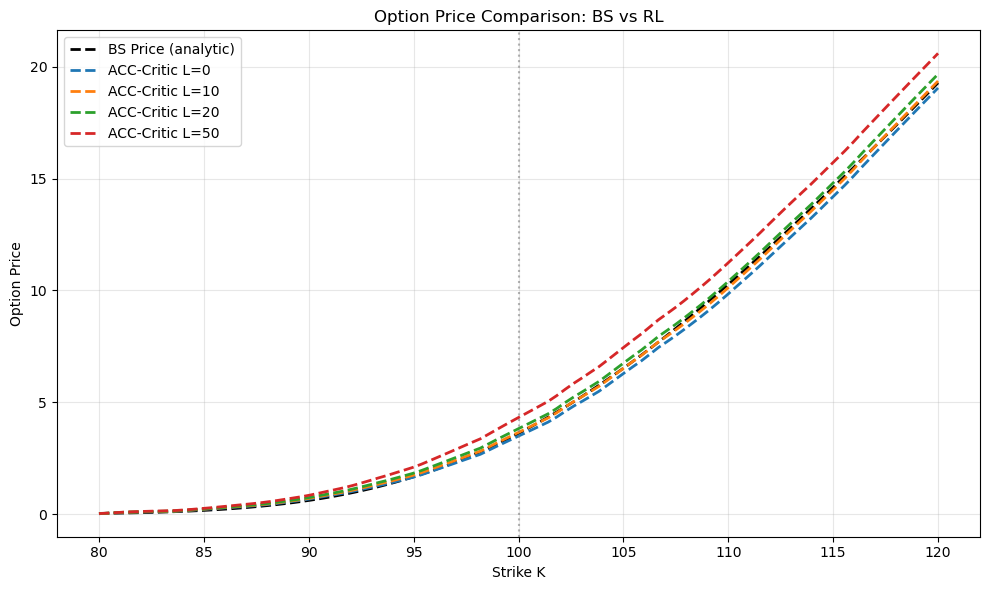

In [378]:
# =============================================================================
# 5. Price comparison plot (BS vs RL)
# =============================================================================

# --- BS analytic price (ground truth) ---
price_bs = pvv.vectorized_black_scholes(
    flag=option_flag,
    S=S0,
    K=K_array,
    t=T,
    r=r,
    sigma=sigma,
    return_as="numpy",
)

# --- Price comparison plot ---
plt.figure(figsize=(10, 6))
plt.plot(
    K_array,
    price_bs,
    "--",
    lw=2,
    color="black",
    label="BS Price (analytic)",
)

plt.plot(
    K_array,
    all_prices_lambdas[0],
            "--",

    lw=2,
    label="ACC-Critic L=0",
)
    # 0, 0.5, 5, 20, 50,

plt.plot(
    K_array,
    all_prices_lambdas[1],
        "--",
    lw=2,
    label=f"ACC-Critic L={LAMBDA_GRID[1]}",
)

plt.plot(
    K_array,
    all_prices_lambdas[2],
        "--",
    lw=2,
    label=f"ACC-Critic L={LAMBDA_GRID[2]}",
)

plt.plot(
    K_array,
    all_prices_lambdas[3],
        "--",
    lw=2,
    label=f"ACC-Critic L={LAMBDA_GRID[3]}",
)

plt.axvline(S0, color="gray", ls=":", alpha=0.6)
plt.xlabel("Strike K")
plt.ylabel("Option Price")
plt.title("Option Price Comparison: BS vs RL")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [379]:
# =============================================================================
# 6. Implied Vol from RL model prices
# =============================================================================
iv_rl = pvv.vectorized_implied_volatility(
    price=price_rl,
    S=S0,
    K=K_array,
    t=T,
    r=r,
    q=0,
    flag=option_flag,
    model="black_scholes_merton",
    on_error="ignore",
    return_as="numpy",
)

# =============================================================================
# 6. Implied Vol from RL model prices
# =============================================================================
pvv_iv_bs = pvv.vectorized_implied_volatility(
    price=price_bs,
    S=S0,
    K=K_array,
    t=T,
    r=r,
    q=0,
    flag=option_flag,
    model="black_scholes_merton",
    on_error="ignore",
    return_as="numpy",
)


iv_critic_all = pvv.vectorized_implied_volatility(
    price=all_prices_lambdas,
    S=S0,
    K=np.expand_dims(K_array, axis=0).repeat(all_prices_lambdas.shape[0], axis=0),
    t=T,
    r=r,
    q=0,
    flag=option_flag,
    model="black_scholes_merton",
    on_error="ignore",
    return_as="numpy",
).reshape(all_prices_lambdas.shape)

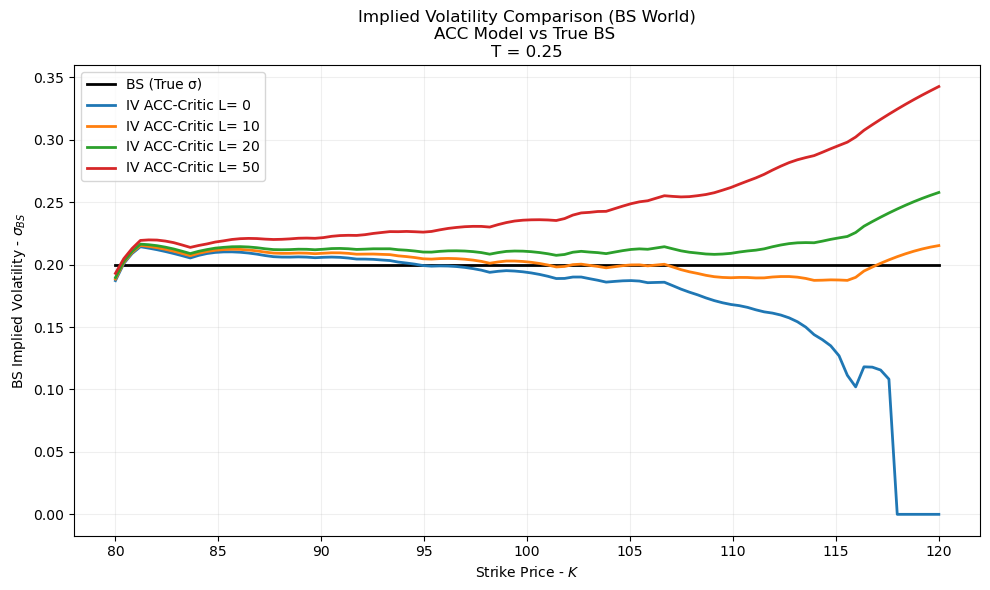

In [380]:
# =============================================================================
# 7. IV Smile plot: BS (true) vs RL
# =============================================================================
plot_iv_smile(
    K_array=K_array,
    smiles={
        "BS (True σ)": {
            "mean": iv_bs,
            "color": "black",
        },
        # "BS (pvv.vectorized_implied_volatility cal)": {
        #     "mean": pvv_iv_bs,
        #     "color": "tab:blue",
        # },
        # "RL Model": {
        #     "mean": iv_rl,
        #     "color": "tab:red",
        # },
        f"IV ACC-Critic L= {LAMBDA_GRID[0]}": {
            "mean": iv_critic_all[0],
            # "color": "tab:green",
        },
        f"IV ACC-Critic L= {LAMBDA_GRID[1]}": {
            "mean": iv_critic_all[1],
            # "color": "tab:green",
        },
        f"IV ACC-Critic L= {LAMBDA_GRID[2]}": {
            "mean": iv_critic_all[2],
            # "color": "tab:green",
        },
        f"IV ACC-Critic L= {LAMBDA_GRID[3]}": {
            "mean": iv_critic_all[3],
            # "color": "tab:green",
        },
        # f"L= {LAMBDA_GRID[4]}": {
        #     "mean": iv_critic_all[4],
        #     # "color": "tab:green",
        # },
    },
    title=(
        "Implied Volatility Comparison (BS World)\n"
        f"ACC Model vs True BS \n"
        f"T = {T}"
    ),
)


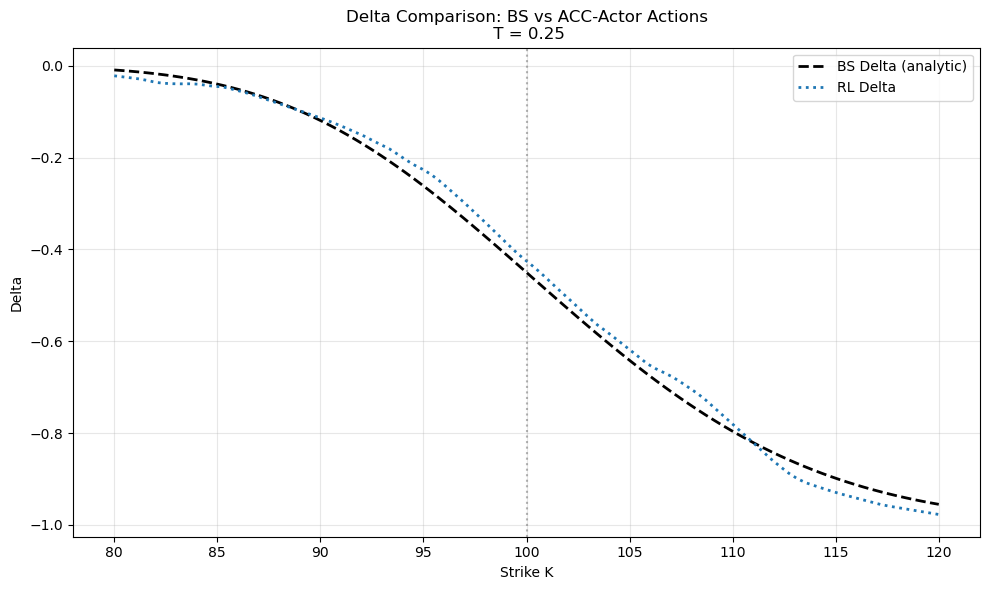

In [381]:
# =============================================================================
# 8. Delta comparison plot
# =============================================================================
plt.figure(figsize=(10, 6))
plt.plot(K_array, delta_bs, "--", label="BS Delta (analytic)", lw=2, color="black")
plt.plot(K_array, delta_rl, ":", label="RL Delta", lw=2, color="tab:blue")
plt.axvline(S0, color="gray", ls=":", alpha=0.6)
plt.xlabel("Strike K")
plt.ylabel("Delta")
plt.title(f"Delta Comparison: BS vs ACC-Actor Actions\n T = {T}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [382]:
@torch.no_grad()
def actor_delta_quantile_band(
    actor,
    state_tensor,        # [nK, state_dim]
    num_quantiles=41,    # 奇数，确保中位数存在
    q_low=0.10,
    q_high=0.90,
):
    """
    Use quantile-based sampling to construct policy band.

    Returns:
        delta_median : [nK]
        delta_low    : [nK]
        delta_high   : [nK]
    """
    actor.eval()

    # Sample action grid (deterministic quantile nodes)
    # shape: [nK, num_quantiles]
    a_grid = actor.sample_n(
        s=state_tensor,
        num_actions=num_quantiles,
        mode="quantile",
        k_sigma=1,
    )

    # Quantiles along action dimension
    delta_low = torch.quantile(a_grid, q_low, dim=1)
    delta_high = torch.quantile(a_grid, q_high, dim=1)
    delta_median = torch.quantile(a_grid, 0.5, dim=1)

    return (
        delta_median.cpu().numpy(),
        delta_low.cpu().numpy(),
        delta_high.cpu().numpy(),
    )


In [383]:
S_over_K = torch.tensor(S0 / K_array, device=device, dtype=torch_dtype)
tau = torch.full_like(S_over_K, T)
state_tensor = make_state_t(S_over_K, tau)


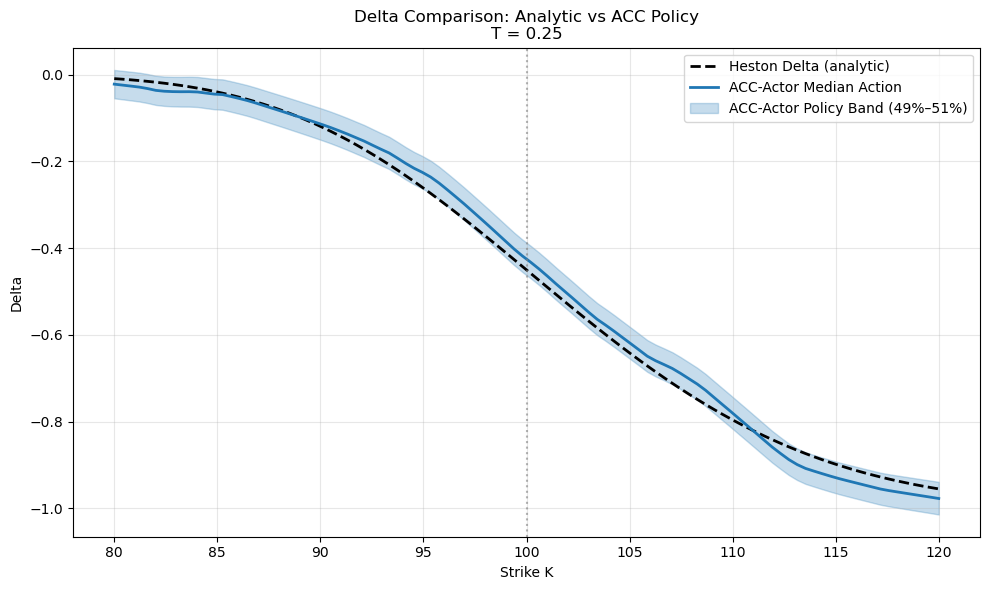

In [384]:
# ==========================================
# Delta comparison plot with policy band
# ==========================================

delta_med, delta_q_low, delta_q_high = actor_delta_quantile_band(
    actor=actor,
    state_tensor=state_tensor,
    num_quantiles=41,
    q_low=0.49,
    q_high=0.51,
)
delta_med = delta_med * (K_array / S0)
delta_q_low = delta_q_low * (K_array / S0)
delta_q_high = delta_q_high * (K_array / S0)

plt.figure(figsize=(10, 6))

# BS delta
plt.plot(
    K_array,
    delta_bs,
    "--",
    color="black",
    lw=2,
    label="Heston Delta (analytic)"  # 或 BS/Heston 按你的环境
)

# ACC median action
plt.plot(
    K_array,
    delta_med,
    lw=2,
    color="tab:blue",
    label="ACC-Actor Median Action",
)

# Policy dispersion band
plt.fill_between(
    K_array,
    delta_q_low,
    delta_q_high,
    color="tab:blue",
    alpha=0.25,
    label="ACC-Actor Policy Band (49%–51%)",
)

plt.axvline(S0, color="gray", ls=":", alpha=0.6)
plt.xlabel("Strike K")
plt.ylabel("Delta")
plt.title(f"Delta Comparison: Analytic vs ACC Policy\nT = {T}")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
